# 2.6.1 Tossing Coins

[42, 58]
tensor([0.4800, 0.5200])

==LLN & CLT==

tensor([[0.0000, 1.0000],
        [0.5000, 0.5000],
        [0.6667, 0.3333],
        ...,
        [0.5014, 0.4986],
        [0.5014, 0.4986],
        [0.5014, 0.4986]])


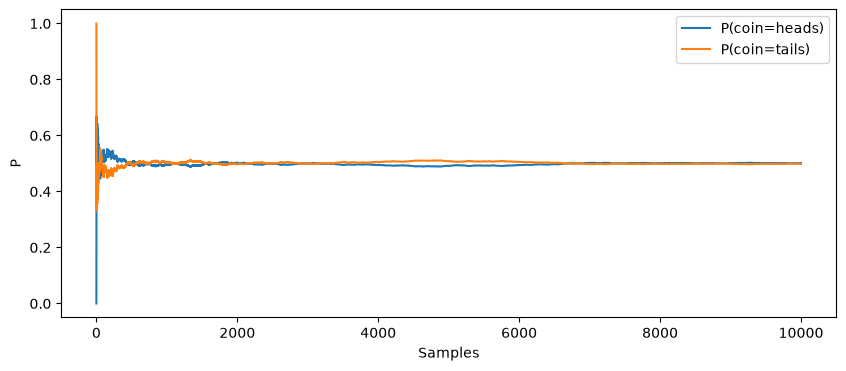

In [35]:
%matplotlib inline
import random 
import torch
from torch.distributions.multinomial import Multinomial
import matplotlib.pyplot as plt

num_tosses=100
heads=sum([random.random()>0.5 for _ in range(num_tosses)])
tails= num_tosses-heads
print([heads,tails])


#or

fair_p=torch.tensor([0.5,0.5])
r=Multinomial(100,fair_p).sample()
freq=r/100
print(freq)

#Let's see the law of large numbers and CLT in action:
print("\n==LLN & CLT==\n")
counts=Multinomial(1,fair_p).sample((10000,))
cum_counts=counts.cumsum(dim=0)
estimates=cum_counts /cum_counts.sum(dim=1, keepdim=True)
print(estimates)
estimates=estimates.numpy()

plt.figure(figsize=(10, 4)) 
plt.plot(estimates[:, 0], label="P(coin=heads)")
plt.plot(estimates[:, 1], label="P(coin=tails)")

plt.xlabel("Samples")
plt.ylabel("P")
plt.legend()
plt.show()